In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import fftconvolve
import IPython.display as ipd
import IPython
import requests
import os
import urllib.request
from scipy.io import wavfile
import io

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

Convolution reverb is a technique that applies the acoustics of a real or virtual space to an audio signal by convolving it with an impulse response recorded in that space.

Convolution reverb uses the mathematical operation of convolution to apply the characteristics of an environment (captured as an impulse response, or IR) to a dry audio signal. This allows you to simulate how a sound would behave in real acoustic spaces.:

**Strengths:**

- Convolution reverb can capture the acoustics of existing places.
- High quality results.

**Drawbacks:**

- Not dynamic.
- Not parametric.
- Computationally complex (for long IRs).

In [2]:
# URLs to download audio files
ir_url = "https://ringbuffer.org/download/audio/ir/kirche_1.wav"
dry_url = "https://ringbuffer.org/download/audio/violin/Solo_DPA_02.wav"
 

-----

# Impulse Responses 

The principle of an impulse response (IR) in acoustics (and for IR reverbs) is the same as in DSP in general:
**A system is excited with an impulse and its response is recorded.**

There are different methods to create that impulse: 

- Handclap
- Balloon Pop
- Starter Pistol

*Another way is to use a sine sweep and transform the response.*

----

## A Stereo IR

IRs can be recorded and applied in any format. Mono, stereo, binaural, Ambisonics, ...
Since stereo has been the dominant format for a long time, there are  countless stereo IRs available.
This example was recorded in a small church (MD, Germany) with a field recorder, using a hand-clap as excitation:


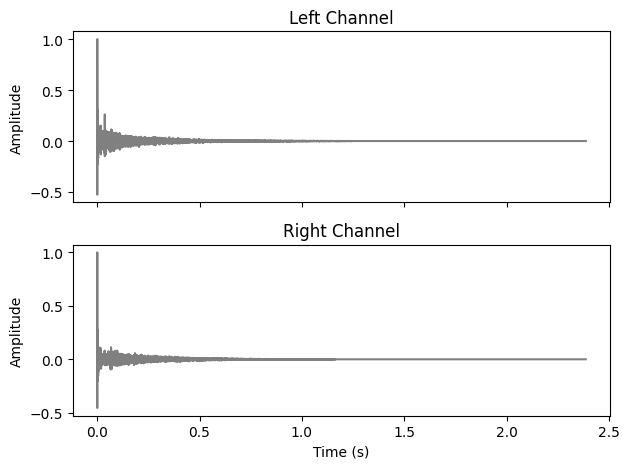

In [3]:
response = urllib.request.urlopen(ir_url)
audio_data = response.read()
        
with io.BytesIO(audio_data) as temp_file:        
    ir_sr, ir = wavfile.read(temp_file)


t = np.linspace(0,len(ir)/ir_sr,len(ir))

# Normalize
ir = ir / np.max(np.abs(ir))
#dry = dry / np.max(np.abs(dry))

IPython.display.display(IPython.display.Audio(url=ir_url, autoplay=False))
    
# Create the subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True) # 2 rows, 1 column, share x-axis

# Plot the left channel
ax1.plot(t, ir[:,0], color = 'gray')
ax1.set_title('Left Channel')
ax1.set_ylabel('Amplitude')

# Plot the right channel
ax2.plot(t, ir[:,1], color = 'gray')
ax2.set_title('Right Channel')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()

In [4]:
response = urllib.request.urlopen(dry_url)
audio_data = response.read()
        
with io.BytesIO(audio_data) as temp_file:        
    dry_sr, dry = wavfile.read(temp_file)

            

# Normalize
dry = dry / np.max(np.abs(dry))
#dry = dry / np.max(np.abs(dry))

 

----

## Applying Convolution

We can convolve the dry audio with the impulse response to simulate reverberation.
Since we have a stereo IR, we perform two convolutions to use the spatial information and create a stereo signal from our mono input.

In [5]:
# Apply convolution
dry_convolved_L = fftconvolve(dry, ir[:,0], mode='full')
dry_convolved_L = dry_convolved_L / np.max(np.abs(dry_convolved_L))

In [6]:
# Apply convolution
dry_convolved_R = fftconvolve(dry, ir[:,1], mode='full')
dry_convolved_R = dry_convolved_R / np.max(np.abs(dry_convolved_R))

----

## Visualizing the Signals
Here we visualize the waveforms for the dry signal, the impulse response, and the resulting reverberated signal.

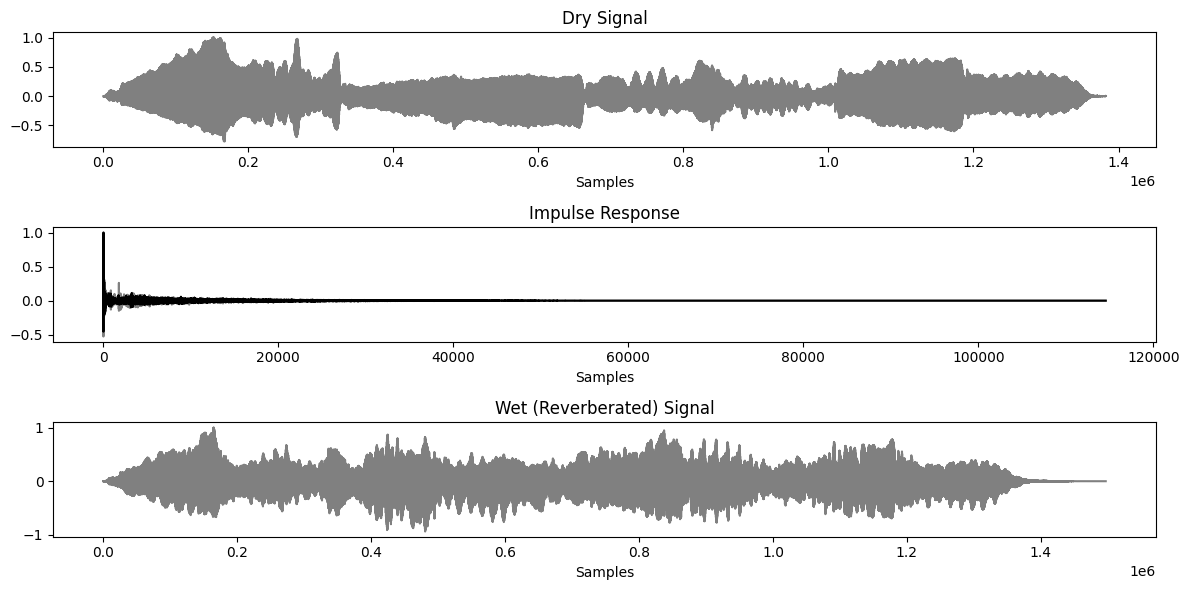

In [7]:

#dry_convolved = [dry_convolved_L , dry_convolved_R]
dry_convolved = dry_convolved_L 

plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
plt.title("Dry Signal")
plt.plot(dry, color = 'gray')
plt.xlabel('Samples')

plt.subplot(3,1,2)
plt.title("Impulse Response")
plt.plot(ir[:,0],color = 'gray')
plt.plot(ir[:,1],color = 'black')
plt.xlabel('Samples')


plt.subplot(3,1,3)
plt.title("Wet (Reverberated) Signal")
plt.plot(dry_convolved, color = 'gray')
plt.xlabel('Samples')

plt.tight_layout()
plt.show()

## Listen to the Audio
Playback of the dry, IR, and wet signals.

In [8]:
print("Dry Audio:")
ipd.display(ipd.Audio(dry, rate=dry_sr))



print("Wet Audio (Reverberated):")
ipd.display(ipd.Audio(dry_convolved, rate=dry_sr))

Dry Audio:


Wet Audio (Reverberated):


----

# Guess That IR

Where has this IR been reorded:

In [11]:
url = 'https://ringbuffer.org/download/audio/ir/IR_wald_1.wav'
if 3 < 5:
    IPython.display.display(IPython.display.Audio(url=url, autoplay=False))
else:
    print('Hello!')
    


---

# Exercise
 

- 1: Download a solo: https://ringbuffer.org/download/audio/solo_instruments/
 
- 2: Download one of these IRs: https://ringbuffer.org/download/audio/ir/

- 3: Apply convolution to create a reverberant version of the solo.